# Exploratory Data Analysis Adult Census

## ???? ?????

??????? ????????? ??????, ????? ????????, ????????? ????????? ???????, ?????????? ????????????? ????????? ? ??????????? ?????? ??? ?????????? ????????????? ? preprocessing.

## ???????? ????????? ? ????????? ?????

??? ??????? ??????????? ? `figures/`, ????? ?????????? ???????????? ???? ???????????????? ? ?????????? ??? ??????.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "adult-census.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RANDOM_STATE = 42

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiment_utils import load_adult_data, split_features_target, get_feature_groups, save_figure

sns.set_theme(style="whitegrid", context="notebook")

## ???????? ??????

?????? ??????????? ?? ?????????? ????? `data/raw/adult-census.csv`. ?????? `?` ???????????????? ??? ???????.

In [2]:
df = load_adult_data(DATA_PATH)
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## ?????? ????????

???????? ?????????? ?????????? ? ?????????.

In [3]:
dataset_shape = pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]})
dataset_shape

,Rows,Columns
0,48842,14


## ???? ?????????

??????? ??????? ?????????? ? ????????? ???????? ? ?????????????? ???????? ?????????????.

In [4]:
X, y = split_features_target(df)
numeric_features, categorical_features = get_feature_groups(X)

feature_types = pd.DataFrame({
    "Feature group": ["Numeric", "Categorical"],
    "Count": [len(numeric_features), len(categorical_features)],
    "Features": [", ".join(numeric_features), ", ".join(categorical_features)],
})
feature_types

,Feature group,Count,Features
0,Numeric,5,"age, education-num, capital-gain, capital-loss..."
1,Categorical,8,"workclass, education, marital-status, occupati..."


## ??????? ?????????

????????? ?????????? ? ???? ??????????? ???????? ?? ??????? ???????.

In [5]:
missing_table = (
    df.isna().sum()
    .rename("Missing values")
    .to_frame()
)
missing_table["Missing %"] = (missing_table["Missing values"] / len(df) * 100).round(2)
missing_table = missing_table.sort_values("Missing values", ascending=False)
missing_table

,Missing values,Missing %
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75
age,0,0.00
education-num,0,0.00
education,0,0.00
marital-status,0,0.00
relationship,0,0.00
sex,0,0.00
race,0,0.00


## ????????????? ??????? ??????????

???????? ?????? ??????? `<=50K` ? `>50K`. ????????????? ????? ??? ??????????? F1-score: `>50K`.

In [6]:
class_counts = y.value_counts().rename_axis("class").reset_index(name="count")
class_counts["share"] = (class_counts["count"] / class_counts["count"].sum()).round(4)
class_counts

,class,count,share
0,<=50K,37155,0.7607
1,>50K,11687,0.2393


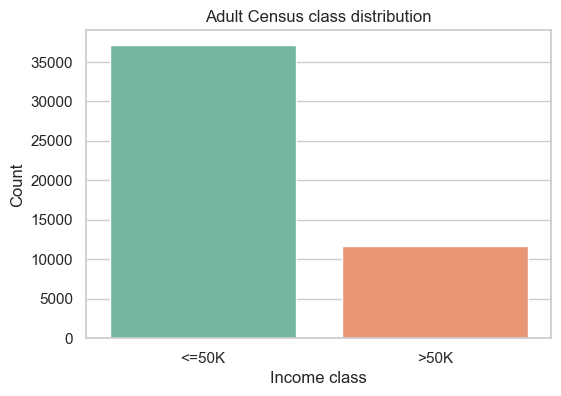

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", order=["<=50K", ">50K"], hue="class", palette="Set2", legend=False)
plt.title("Adult Census class distribution")
plt.xlabel("Income class")
plt.ylabel("Count")
save_figure(FIGURES_DIR / "adult_class_distribution.png")
plt.show()

## ???????? ????? ?????????

?????? ??????????, ? ????? ????????? ??????????? ????????. ?? ????? ??? ?????? ??????? ?????????.

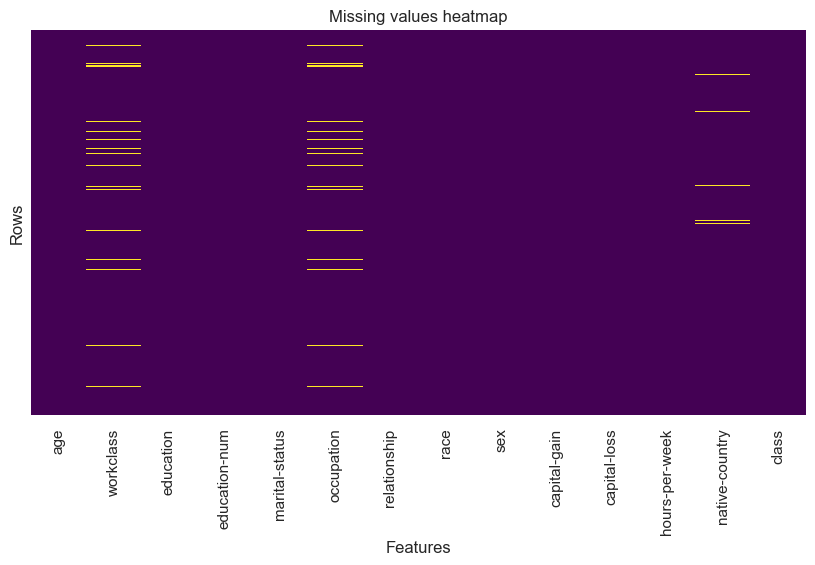

In [8]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values heatmap")
plt.xlabel("Features")
plt.ylabel("Rows")
save_figure(FIGURES_DIR / "adult_missing_values.png")
plt.show()

## ????????????? ????????

??????? ???????? ????? ?? ???????? ???????? ?????????, ??????? ????????? ??? ?????????????.

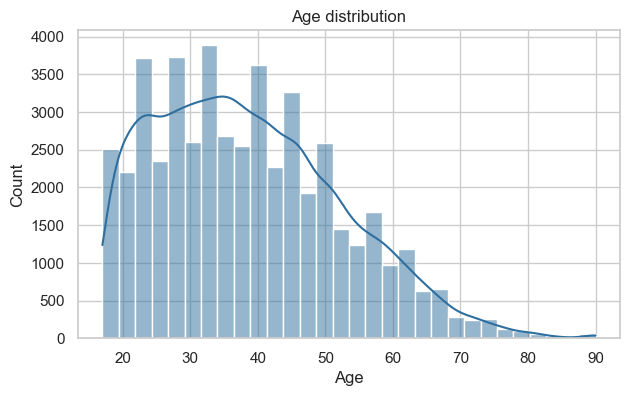

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", bins=30, kde=True, color="#2f6f9f")
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")
save_figure(FIGURES_DIR / "adult_age_distribution.png")
plt.show()

## ????????????? ????? ?????? ? ??????

??????? `hours-per-week` ????? ???? ?????? ? ??????? ??????, ?? ??????? ????? ?????????? ??? ????? ? ???????.

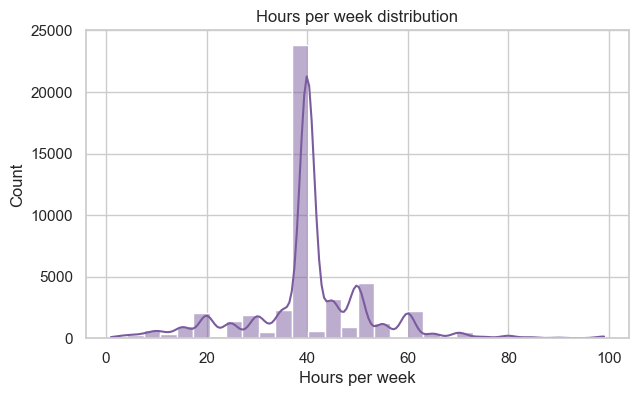

In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="hours-per-week", bins=30, kde=True, color="#7a5c9e")
plt.title("Hours per week distribution")
plt.xlabel("Hours per week")
plt.ylabel("Count")
save_figure(FIGURES_DIR / "adult_hours_distribution.png")
plt.show()

## ??????? ?? ??????? ??????

Boxplot ???????? ???????? ????????????? ???????? ?????? ???? ??????? ??????? ??????????.

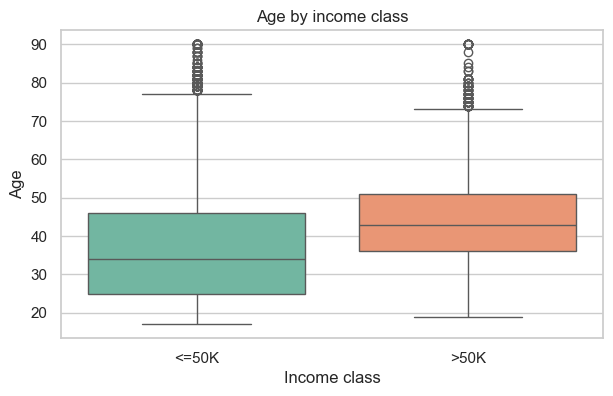

In [11]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="class", y="age", order=["<=50K", ">50K"], hue="class", palette="Set2", legend=False)
plt.title("Age by income class")
plt.xlabel("Income class")
plt.ylabel("Age")
save_figure(FIGURES_DIR / "adult_age_by_class_boxplot.png")
plt.show()

## ?????????????? ??????? ???????? ?????????

???????? ???????? ????? ????? ????????? ??????????. ?????????? ?? ????????? ?????????????? ???????? ? ?? ?????????? ???????????.

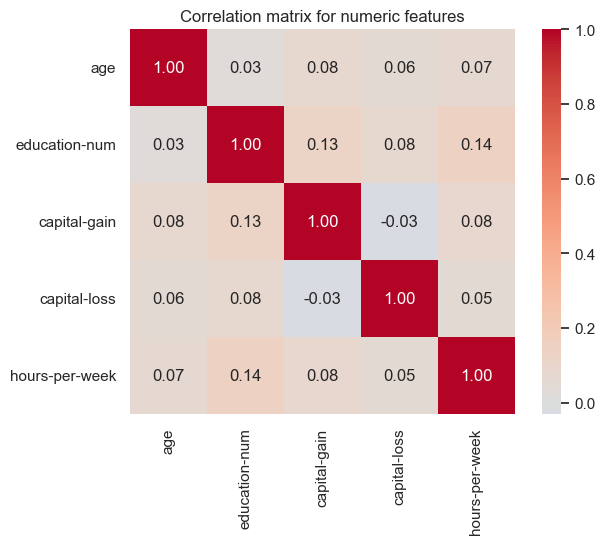

In [12]:
corr_matrix = df[numeric_features].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix for numeric features")
save_figure(FIGURES_DIR / "adult_correlation_matrix.png")
plt.show()

## ???????? ?????? ?? EDA

- ? ?????? ???? ????????? ???????: ????? `<=50K` ??????????? ??????? ????, ??? `>50K`, ??????? Accuracy ?????? ????????????? ??? ???????????? ???????.
- ???????? ????????????? ? ?????????????? ?????????, ??????? ? pipeline ????? ????????? ??? ?????????????? ? ???????? ?????????.
- ????????????? ???????? ????????? ?? ???????? ???????????; ??? ???????? ??????? ????? ????????? ???????????????.
- ?? ?????????????? ??????? ???????? ????????? ?? ????? ??????? ???????? ??????????? ????? ???????????? ?????????, ??????? ?????? ?????????? ? ?????????? ???????????????????? ?????? ?? ????????? ????? ???????.
- ?????????? ???????????? ?????? ???????????? `Pipeline` ? `ColumnTransformer`, ????? preprocessing ???????? ?????? ?? train-?????.